# Prediction Accuracy Analysis

How good were our projections vs reality? And more importantly — were we better than Sleeper?

**Coverage:** Weeks 10–16 (2025 season), 5 projection sources, 12-team league.

1. Player-level accuracy by source
2. Accuracy by player tier
3. Biggest disagreements: TNCasino vs Sleeper
4. Team-level accuracy
5. Over/under line accuracy
6. Matchup prediction scoreboard

In [1]:
import sqlite3
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#16213e",
    "axes.edgecolor": "#e0e0e0",
    "axes.labelcolor": "#e0e0e0",
    "text.color": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0",
    "grid.color": "#2a2a4a",
    "font.family": "sans-serif",
    "font.size": 11,
})

TNCASINO_COLOR = "#00d4aa"
SLEEPER_COLOR = "#7c83ff"

for candidate in [Path("../data/databases"), Path("backend/data/databases"), Path("../../backend/data/databases")]:
    if (candidate / "projections.db").exists():
        DB_DIR = candidate
        break

conn_proj = sqlite3.connect(DB_DIR / "projections.db")
conn_league = sqlite3.connect(DB_DIR / "league.db")
conn_odds = sqlite3.connect(DB_DIR / "odds.db")
conn_mc = sqlite3.connect(DB_DIR / "montecarlo.db")
print(f"Connected to: {DB_DIR.resolve()}")


def accuracy_metrics(df, error_col="error", abs_error_col="abs_error"):
    return pd.Series({
        "MAE": df[abs_error_col].mean(),
        "RMSE": np.sqrt((df[error_col] ** 2).mean()),
        "Bias": df[error_col].mean(),
        "Players": len(df),
    })

Connected to: C:\Users\Samer Faizi\Documents\Claude Model\backend\data\databases


In [2]:
# ==================== LOAD DATA ====================

source_proj = pd.read_sql("""
    SELECT sleeper_player_id, source_website, week, projected_points, position
    FROM projections_with_sleeper
""", conn_proj)
source_proj["week_num"] = source_proj["week"].str.extract(r"(\d+)").astype(int)

blended = pd.read_sql("""
    SELECT sleeper_player_id, player_name, position, week, mu, sigma, n_sources
    FROM player_week_stats
""", conn_proj)

actuals = pd.read_sql("""
    SELECT player_id, week, pts_ppr FROM player_stats
    WHERE week >= 10 AND pts_ppr > 0
""", conn_league)
actuals["player_id"] = actuals["player_id"].astype(str)

team_proj = pd.read_sql("""
    SELECT roster_id, owner, week, total_mu, combined_sigma
    FROM team_projections_summary
""", conn_proj)

matchups = pd.read_sql("""
    SELECT roster_id, week, matchup_id_number, points, starters
    FROM matchups WHERE week >= 10
""", conn_league)
owner_map = dict(zip(team_proj["roster_id"], team_proj["owner"]))
matchups["owner"] = matchups["roster_id"].map(owner_map)

# Join projections to actuals
source_vs_actual = source_proj.merge(
    actuals, left_on=["sleeper_player_id", "week_num"], right_on=["player_id", "week"], how="inner"
)
source_vs_actual["error"] = source_vs_actual["projected_points"] - source_vs_actual["pts_ppr"]
source_vs_actual["abs_error"] = source_vs_actual["error"].abs()

blended_vs_actual = blended.merge(
    actuals, left_on=["sleeper_player_id", "week"], right_on=["player_id", "week"], how="inner"
)
blended_vs_actual["error"] = blended_vs_actual["mu"] - blended_vs_actual["pts_ppr"]
blended_vs_actual["abs_error"] = blended_vs_actual["error"].abs()

print(f"Source projections: {len(source_proj):,} | Blended: {len(blended):,} | Actuals: {len(actuals):,}")
print(f"Joined: {len(source_vs_actual):,} source-to-actual | {len(blended_vs_actual):,} blended-to-actual")

Source projections: 11,634 | Blended: 4,000 | Actuals: 2,525
Joined: 7,776 source-to-actual | 2,197 blended-to-actual


---
## 1. Player-Level Accuracy by Source

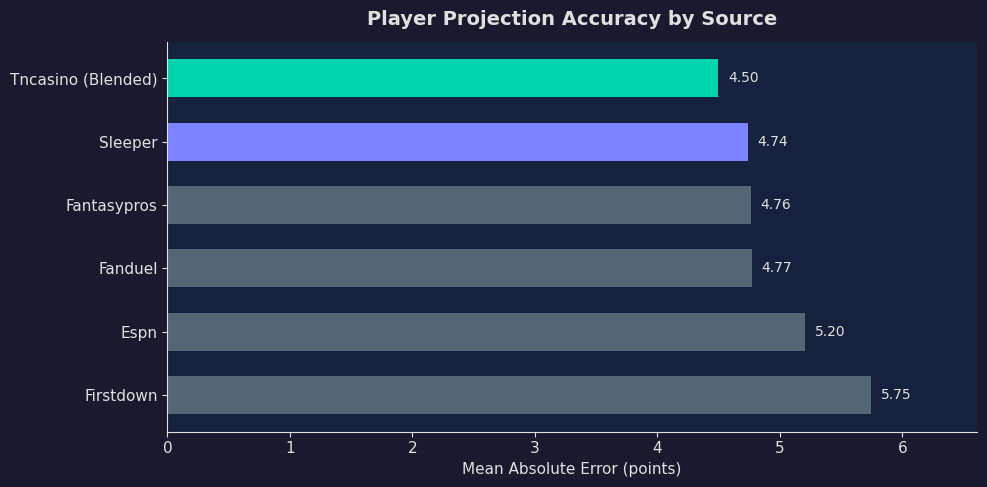

                    MAE  RMSE  Bias  Players
TNCasino (blended) 4.50  6.19 -0.78     2197
sleeper.com        4.74  6.41 -0.15     1937
fantasypros.com    4.76  6.51 -0.79     1934
fanduel.com        4.77  6.52 -0.85     1803
espn.com           5.20  6.82 -0.12     1411
firstdown.studio   5.75  7.60 -1.33      691


In [3]:
source_table = source_vs_actual.groupby("source_website").apply(
    accuracy_metrics, include_groups=False
).sort_values("MAE")
blended_row = accuracy_metrics(blended_vs_actual)
blended_row.name = "TNCasino (blended)"
player_accuracy = pd.concat([source_table, blended_row.to_frame().T])
player_accuracy["Players"] = player_accuracy["Players"].astype(int)
player_accuracy = player_accuracy.sort_values("MAE")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
pa = player_accuracy.sort_values("MAE", ascending=True)
colors = [TNCASINO_COLOR if "TNCasino" in n else SLEEPER_COLOR if "sleeper" in n else "#556677" for n in pa.index]
labels = [n.replace(".com", "").replace(".studio", "").replace("_", " ").title() for n in pa.index]

bars = ax.barh(labels, pa["MAE"], color=colors, edgecolor="none", height=0.6)
ax.set_xlabel("Mean Absolute Error (points)")
ax.set_title("Player Projection Accuracy by Source", fontsize=14, fontweight="bold", pad=12)
ax.invert_yaxis()
ax.set_xlim(0, pa["MAE"].max() * 1.15)
for bar, val in zip(bars, pa["MAE"]):
    ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=10, color="#e0e0e0")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(player_accuracy.to_string())

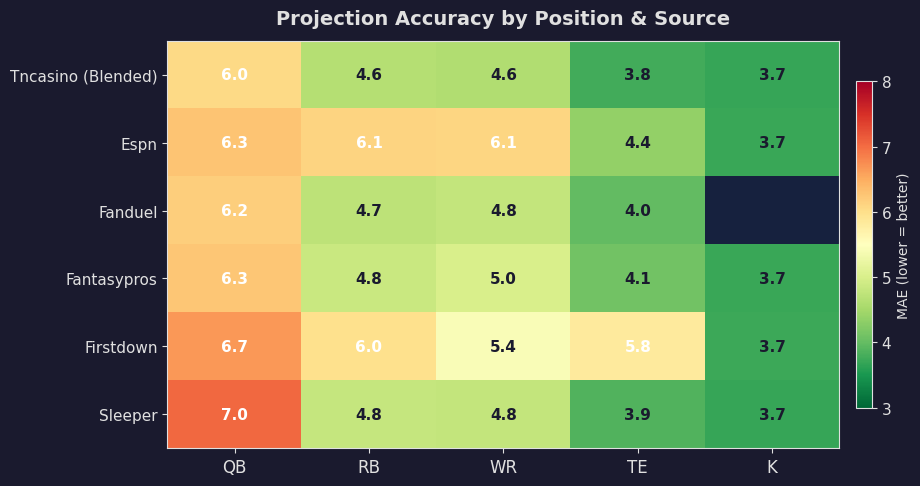

In [4]:
# --- Position x Source heatmap ---
positions = ["QB", "RB", "WR", "TE", "K"]

pos_source = (
    source_vs_actual[source_vs_actual["position"].isin(positions)]
    .groupby(["position", "source_website"]).apply(accuracy_metrics, include_groups=False).reset_index()
)
pos_blended = (
    blended_vs_actual[blended_vs_actual["position"].isin(positions)]
    .groupby("position").apply(accuracy_metrics, include_groups=False).reset_index()
)
pos_blended["source_website"] = "TNCasino (blended)"
pos_accuracy = pd.concat([pos_source, pos_blended])

pivot_data = pos_accuracy.pivot_table(index="source_website", columns="position", values="MAE")[positions]
display_labels = [n.replace(".com", "").replace(".studio", "").replace("_", " ").title() for n in pivot_data.index]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_data.values, cmap="RdYlGn_r", aspect="auto", vmin=3, vmax=8)
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontsize=12)
ax.set_yticks(range(len(display_labels)))
ax.set_yticklabels(display_labels, fontsize=11)
for i in range(len(display_labels)):
    for j in range(len(positions)):
        val = pivot_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white" if val > 5.5 else "#1a1a2e")
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("MAE (lower = better)", fontsize=10)
ax.set_title("Projection Accuracy by Position & Source", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

---
## 2. Accuracy by Player Tier

Players tiered by our blended model rankings each week (top 12 projected QBs = QB1, 13–24 = QB2, etc).

In [5]:
tier_rules = {
    "QB": [(1, 12, "QB1"), (13, 24, "QB2")],
    "RB": [(1, 12, "RB1"), (13, 24, "RB2"), (25, 36, "RB3")],
    "WR": [(1, 12, "WR1"), (13, 24, "WR2"), (25, 36, "WR3")],
    "TE": [(1, 12, "TE1"), (13, 24, "TE2")],
    "K":  [(1, 12, "K1")],
}

tiers = []
for (pos, week), group in blended.groupby(["position", "week"]):
    if pos not in tier_rules:
        continue
    ranked = group.sort_values("mu", ascending=False).reset_index(drop=True)
    ranked["rank"] = ranked.index + 1
    for lo, hi, tier_name in tier_rules[pos]:
        tier_slice = ranked[(ranked["rank"] >= lo) & (ranked["rank"] <= hi)].copy()
        tier_slice["tier"] = tier_name
        tiers.append(tier_slice)

tier_df = pd.concat(tiers)[["sleeper_player_id", "week", "tier"]]

source_with_tier = source_proj.merge(
    tier_df, left_on=["sleeper_player_id", "week_num"], right_on=["sleeper_player_id", "week"]
).merge(actuals, left_on=["sleeper_player_id", "week_num"], right_on=["player_id", "week"], how="inner")
source_with_tier["abs_error"] = (source_with_tier["projected_points"] - source_with_tier["pts_ppr"]).abs()

blended_with_tier = blended.merge(tier_df, on=["sleeper_player_id", "week"]).merge(
    actuals, left_on=["sleeper_player_id", "week"], right_on=["player_id", "week"], how="inner"
)
blended_with_tier["abs_error"] = (blended_with_tier["mu"] - blended_with_tier["pts_ppr"]).abs()

source_tier_agg = source_with_tier.groupby(["tier", "source_website"]).agg(
    MAE=("abs_error", "mean"), n=("abs_error", "count")
).reset_index()
blended_tier_agg = blended_with_tier.groupby("tier").agg(
    MAE=("abs_error", "mean"), n=("abs_error", "count")
).reset_index()
blended_tier_agg["source_website"] = "TNCasino (blended)"
all_tier_accuracy = pd.concat([source_tier_agg, blended_tier_agg])

tier_order = ["QB1", "QB2", "RB1", "RB2", "RB3", "WR1", "WR2", "WR3", "TE1", "TE2", "K1"]
source_order = ["TNCasino (blended)", "sleeper.com", "fanduel.com", "fantasypros.com", "espn.com", "firstdown.studio"]
source_labels = ["TNCasino", "Sleeper", "FanDuel", "FantasyPros", "ESPN", "FirstDown"]

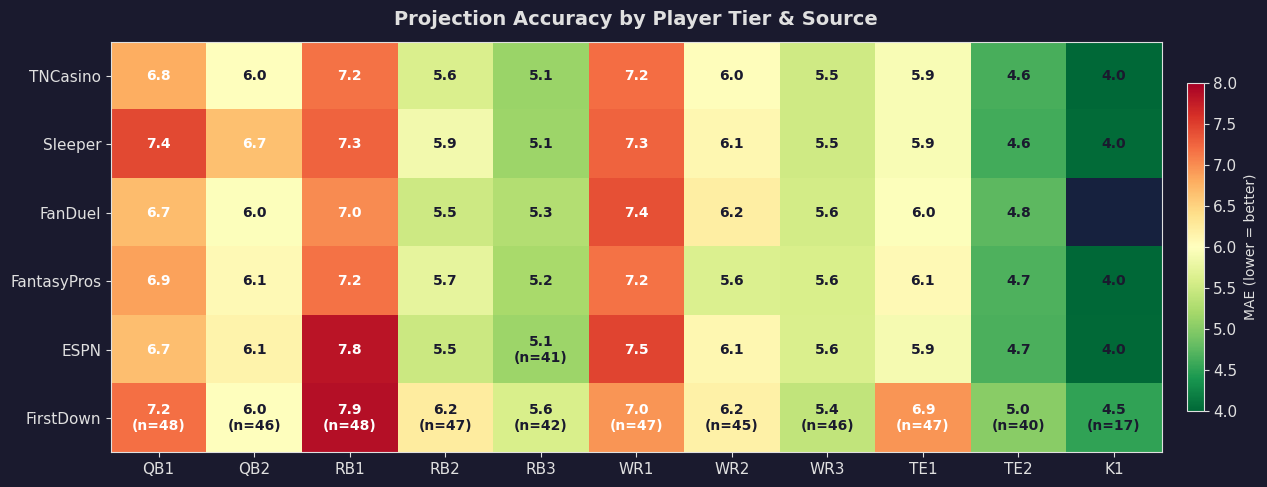

In [6]:
# --- Tier heatmap ---
pivot_mae = all_tier_accuracy.pivot_table(index="source_website", columns="tier", values="MAE")
pivot_n = all_tier_accuracy.pivot_table(index="source_website", columns="tier", values="n")
pivot_mae = pivot_mae.reindex(index=source_order, columns=tier_order)
pivot_n = pivot_n.reindex(index=source_order, columns=tier_order)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot_mae.values, cmap="RdYlGn_r", aspect="auto", vmin=4, vmax=8)
ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels(tier_order, fontsize=11)
ax.set_yticks(range(len(source_labels)))
ax.set_yticklabels(source_labels, fontsize=11)
for i in range(len(source_labels)):
    for j in range(len(tier_order)):
        mae_val = pivot_mae.values[i, j]
        n_val = pivot_n.values[i, j]
        if not np.isnan(mae_val):
            n_str = f"\n(n={int(n_val)})" if n_val < 50 else ""
            ax.text(j, i, f"{mae_val:.1f}{n_str}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if mae_val > 6.5 else "#1a1a2e")
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("MAE (lower = better)", fontsize=10)
ax.set_title("Projection Accuracy by Player Tier & Source", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

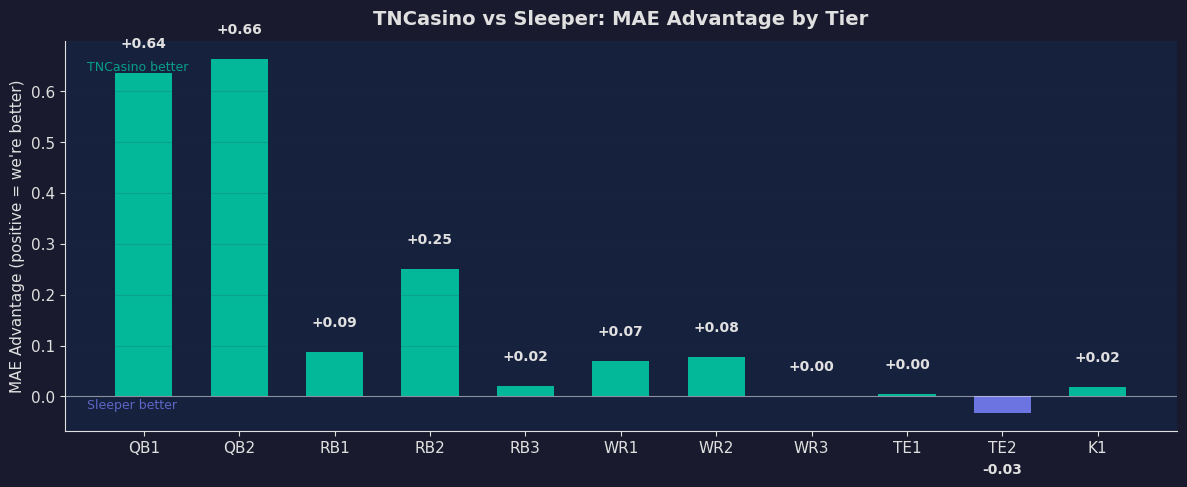

Tier wins by source:
  TNCasino (blended)      4 tiers
  espn                    3 tiers
  fanduel                 3 tiers
  fantasypros             2 tiers
  firstdown               2 tiers
  sleeper                 1 tiers


In [7]:
# --- TNCasino vs Sleeper advantage by tier ---
our_mae = all_tier_accuracy[all_tier_accuracy["source_website"] == "TNCasino (blended)"].set_index("tier")["MAE"]
slp_mae = all_tier_accuracy[all_tier_accuracy["source_website"] == "sleeper.com"].set_index("tier")["MAE"]
advantage = (slp_mae - our_mae).reindex(tier_order).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [TNCASINO_COLOR if v > 0 else SLEEPER_COLOR for v in advantage]
bars = ax.bar(advantage.index, advantage.values, color=colors_bar, edgecolor="none", width=0.6, alpha=0.85)
ax.axhline(0, color="#ffffff", linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, advantage.values):
    y_offset = 0.05 if val >= 0 else -0.12
    ax.text(bar.get_x() + bar.get_width() / 2, val + y_offset,
            f"{val:+.2f}", ha="center", fontsize=10, fontweight="bold", color="#e0e0e0")
ax.set_ylabel("MAE Advantage (positive = we're better)")
ax.set_title("TNCasino vs Sleeper: MAE Advantage by Tier", fontsize=14, fontweight="bold", pad=12)
ax.grid(True, axis="y", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(0.02, 0.95, "TNCasino better", transform=ax.transAxes, fontsize=9, color=TNCASINO_COLOR, alpha=0.7, va="top")
ax.text(0.02, 0.05, "Sleeper better", transform=ax.transAxes, fontsize=9, color=SLEEPER_COLOR, alpha=0.7, va="bottom")
plt.tight_layout()
plt.show()

wins = all_tier_accuracy.loc[all_tier_accuracy.groupby("tier")["MAE"].idxmin()]
win_counts = wins["source_website"].value_counts()
print("Tier wins by source:")
for src, count in win_counts.items():
    print(f"  {src.replace('.com','').replace('.studio',''):<22s}  {count} tiers")

---
## 3. Biggest Disagreements: TNCasino vs Sleeper

When our model and Sleeper disagreed the most on a player — who was closer to reality?

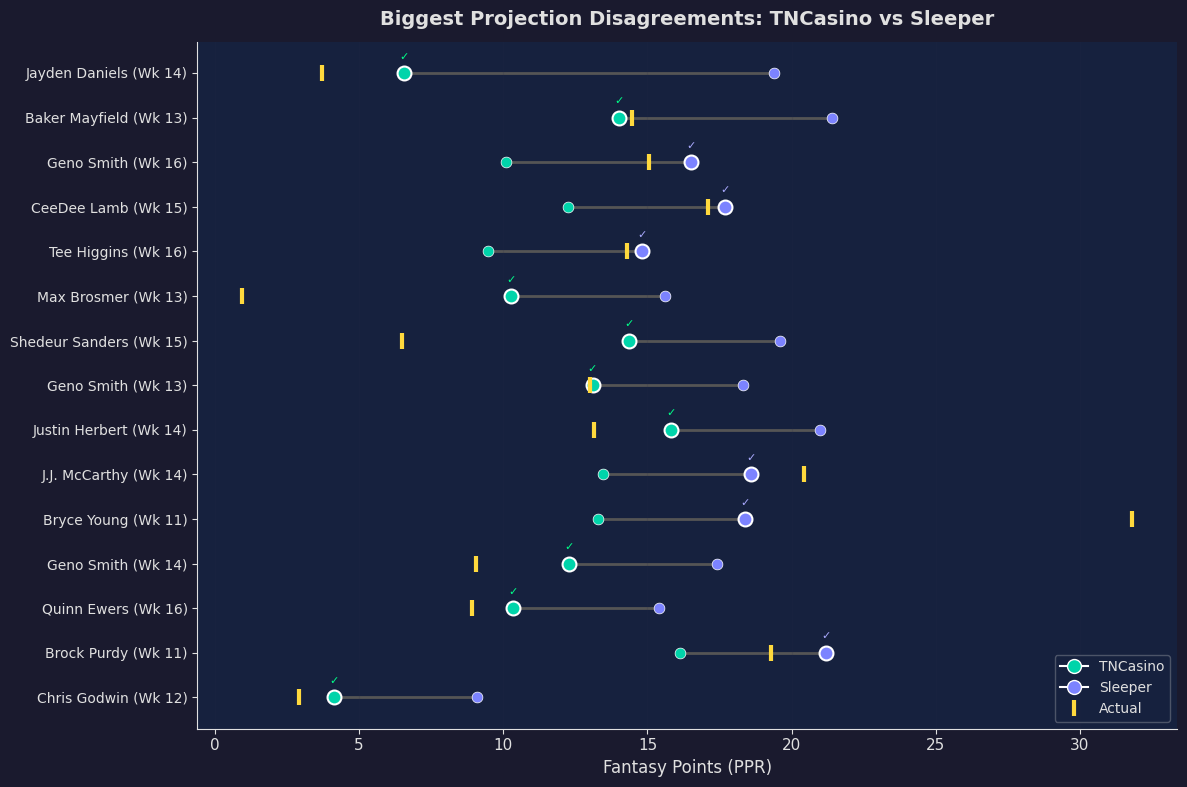

Top 15 disagreements: TNCasino closer 9/15


In [8]:
sleeper_df = source_proj[source_proj["source_website"] == "sleeper.com"][
    ["sleeper_player_id", "week_num", "projected_points"]
].copy()
sleeper_df.columns = ["sleeper_player_id", "week", "sleeper_pts"]

player_disagree = (
    blended[["sleeper_player_id", "player_name", "position", "week", "mu"]]
    .merge(sleeper_df, on=["sleeper_player_id", "week"], how="inner")
    .merge(actuals, left_on=["sleeper_player_id", "week"], right_on=["player_id", "week"], how="inner")
)
player_disagree["model_diff"] = player_disagree["mu"] - player_disagree["sleeper_pts"]
player_disagree["our_error"] = (player_disagree["mu"] - player_disagree["pts_ppr"]).abs()
player_disagree["sleeper_error"] = (player_disagree["sleeper_pts"] - player_disagree["pts_ppr"]).abs()
player_disagree["we_closer"] = player_disagree["our_error"] < player_disagree["sleeper_error"]
player_disagree["diff_abs"] = player_disagree["model_diff"].abs()
player_disagree["label"] = player_disagree["player_name"] + " (Wk " + player_disagree["week"].astype(str) + ")"

top = player_disagree.reindex(
    player_disagree["diff_abs"].sort_values(ascending=False).index
).head(15).iloc[::-1]

# --- Dumbbell chart with winner highlight ---
fig, ax = plt.subplots(figsize=(12, 8))
for i, (_, row) in enumerate(top.iterrows()):
    ax.plot([row["mu"], row["sleeper_pts"]], [i, i], color="#555555", linewidth=2, zorder=1)

    # Highlight the winner with a larger dot
    our_size = 100 if row["we_closer"] else 60
    slp_size = 60 if row["we_closer"] else 100
    our_edge = 1.5 if row["we_closer"] else 0.5
    slp_edge = 0.5 if row["we_closer"] else 1.5
    ax.scatter(row["mu"], i, color=TNCASINO_COLOR, s=our_size, zorder=3, edgecolors="white", linewidth=our_edge)
    ax.scatter(row["sleeper_pts"], i, color=SLEEPER_COLOR, s=slp_size, zorder=3, edgecolors="white", linewidth=slp_edge)
    ax.scatter(row["pts_ppr"], i, color="#ffd93d", s=120, zorder=4, marker="|", linewidths=3)

    # Small check mark next to the winner
    winner_x = row["mu"] if row["we_closer"] else row["sleeper_pts"]
    ax.text(winner_x, i + 0.3, "\u2713", ha="center", fontsize=8, color="#00ff88" if row["we_closer"] else "#aaaaff")

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["label"], fontsize=10)
ax.set_xlabel("Fantasy Points (PPR)", fontsize=12)
ax.set_title("Biggest Projection Disagreements: TNCasino vs Sleeper", fontsize=14, fontweight="bold", pad=12)
ax.grid(True, axis="x", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor=TNCASINO_COLOR, markersize=10, label="TNCasino"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=SLEEPER_COLOR, markersize=10, label="Sleeper"),
    Line2D([0], [0], marker="|", color="#ffd93d", markersize=12, linewidth=0, markeredgewidth=3, label="Actual"),
], loc="lower right", fontsize=10, framealpha=0.3)
plt.tight_layout()
plt.show()

our_wins = top["we_closer"].sum()
print(f"Top 15 disagreements: TNCasino closer {our_wins}/15")

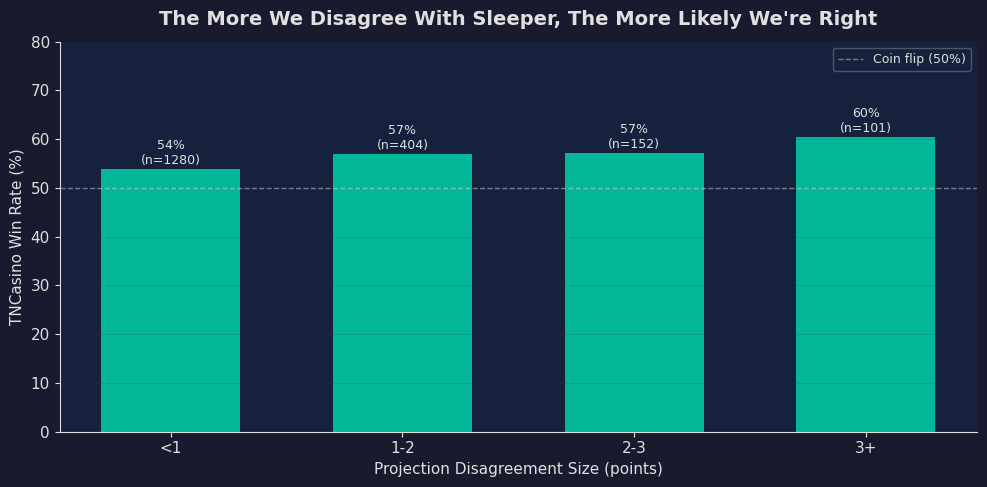

In [9]:
# --- Win rate by disagreement size ---
bins = [(0, 1, "<1"), (1, 2, "1-2"), (2, 3, "2-3"), (3, 100, "3+")]
bin_data = []
for lo, hi, label in bins:
    subset = player_disagree[(player_disagree["diff_abs"] >= lo) & (player_disagree["diff_abs"] < hi)]
    if len(subset) >= 5:
        bin_data.append({"range": label, "win_rate": subset["we_closer"].mean(), "n": len(subset)})

bd = pd.DataFrame(bin_data)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bd["range"], bd["win_rate"] * 100, color=TNCASINO_COLOR, edgecolor="none", width=0.6, alpha=0.85)
ax.axhline(50, color="#ffffff", linewidth=1, linestyle="--", alpha=0.4, label="Coin flip (50%)")

for bar, (_, row) in zip(bars, bd.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{row['win_rate']:.0%}\n(n={int(row['n'])})", ha="center", fontsize=9, color="#e0e0e0")

ax.set_xlabel("Projection Disagreement Size (points)")
ax.set_ylabel("TNCasino Win Rate (%)")
ax.set_title("The More We Disagree With Sleeper, The More Likely We're Right",
             fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(0, 80)
ax.grid(True, axis="y", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9, framealpha=0.3)
plt.tight_layout()
plt.show()

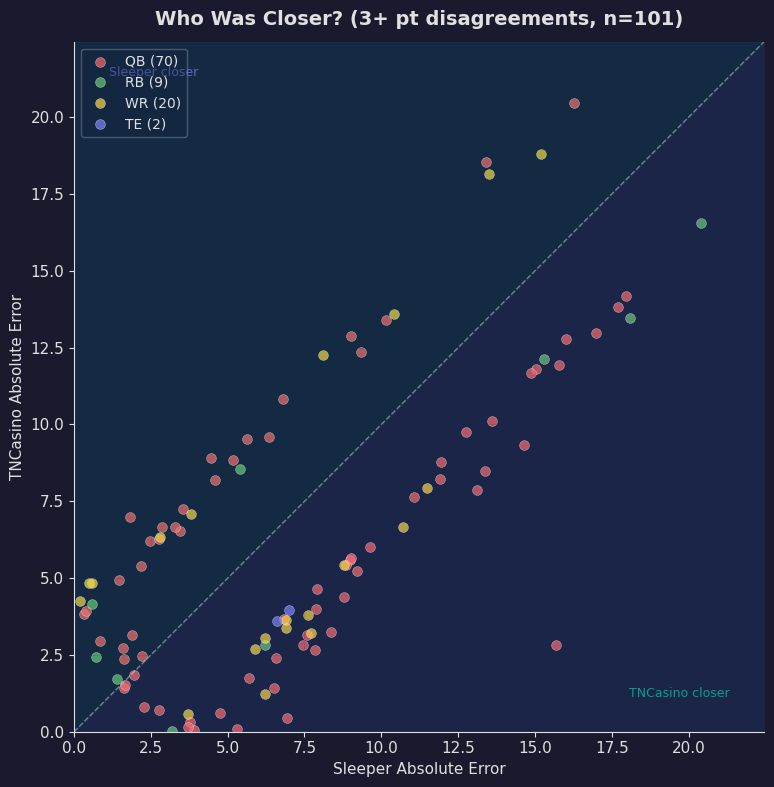

Points below diagonal (TNCasino closer): 61/101 (60%)
TNCasino avg error: 6.4 | Sleeper avg error: 7.4 | Advantage: 1.0 pts


In [10]:
# --- Error comparison scatter (3+ pt disagreements) ---
big = player_disagree[player_disagree["diff_abs"] >= 3].copy()
pos_colors = {"QB": "#ff6b6b", "RB": "#6bcb77", "WR": "#ffd93d", "TE": "#7c83ff", "K": "#e0e0e0"}

fig, ax = plt.subplots(figsize=(8, 8))

for pos in ["QB", "RB", "WR", "TE"]:
    subset = big[big["position"] == pos]
    ax.scatter(subset["sleeper_error"], subset["our_error"],
               color=pos_colors.get(pos, "#888"), s=50, alpha=0.7, label=f"{pos} ({len(subset)})", edgecolors="white", linewidth=0.3)

lo, hi = 0, max(big["our_error"].max(), big["sleeper_error"].max()) + 2
ax.plot([lo, hi], [lo, hi], "--", color="#ffffff", alpha=0.4, linewidth=1)
ax.fill_between([lo, hi], [lo, hi], [hi, hi], color=TNCASINO_COLOR, alpha=0.05)
ax.fill_between([lo, hi], [lo, lo], [lo, hi], color=SLEEPER_COLOR, alpha=0.05)

ax.text(0.95, 0.05, "TNCasino closer", transform=ax.transAxes, ha="right", fontsize=9, color=TNCASINO_COLOR, alpha=0.7)
ax.text(0.05, 0.95, "Sleeper closer", transform=ax.transAxes, ha="left", fontsize=9, color=SLEEPER_COLOR, alpha=0.7)

ax.set_xlabel("Sleeper Absolute Error")
ax.set_ylabel("TNCasino Absolute Error")
ax.set_title(f"Who Was Closer? (3+ pt disagreements, n={len(big)})", fontsize=14, fontweight="bold", pad=12)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.3, loc="upper left")
plt.tight_layout()
plt.show()

print(f"Points below diagonal (TNCasino closer): {big['we_closer'].sum()}/{len(big)} ({big['we_closer'].mean():.0%})")
print(f"TNCasino avg error: {big['our_error'].mean():.1f} | Sleeper avg error: {big['sleeper_error'].mean():.1f} | Advantage: {big['sleeper_error'].mean() - big['our_error'].mean():.1f} pts")

---
## 4. Team-Level Accuracy

In [11]:
# Sum projections for actual starters each week.
# Sleeper API omits DSTs, so DST starters fall back to blended projection.
sleeper_lookup = dict(zip(
    zip(source_proj[source_proj["source_website"] == "sleeper.com"]["sleeper_player_id"],
        source_proj[source_proj["source_website"] == "sleeper.com"]["week_num"]),
    source_proj[source_proj["source_website"] == "sleeper.com"]["projected_points"]
))
blended_lookup = dict(zip(zip(blended["sleeper_player_id"], blended["week"]), blended["mu"]))
opt_lookup = dict(zip(zip(team_proj["roster_id"], team_proj["week"]), team_proj["total_mu"]))

rows = []
for _, m in matchups.iterrows():
    week = m["week"]
    starters = ast.literal_eval(m["starters"]) if isinstance(m["starters"], str) else []
    sleeper_total = blended_total = 0.0
    for pid in starters:
        key = (str(pid), week)
        is_dst = not str(pid).isdigit()
        if key in blended_lookup:
            blended_total += blended_lookup[key]
        if key in sleeper_lookup:
            sleeper_total += sleeper_lookup[key]
        elif is_dst and key in blended_lookup:
            sleeper_total += blended_lookup[key]
    rows.append({
        "roster_id": m["roster_id"], "owner": m["owner"], "week": week,
        "matchup_id": m["matchup_id_number"], "actual": float(m["points"]),
        "sleeper_proj": sleeper_total, "blended_proj": blended_total,
        "our_proj_optimized": opt_lookup.get((m["roster_id"], week), float("nan")),
    })

team_comparison = pd.DataFrame(rows)
team_comparison["our_error"] = (team_comparison["blended_proj"] - team_comparison["actual"]).abs()
team_comparison["sleeper_error"] = (team_comparison["sleeper_proj"] - team_comparison["actual"]).abs()

for label, proj in [("TNCasino", "blended_proj"), ("Sleeper", "sleeper_proj")]:
    mae = (team_comparison[proj] - team_comparison["actual"]).abs().mean()
    bias = (team_comparison[proj] - team_comparison["actual"]).mean()
    print(f"{label:12s}  MAE: {mae:5.1f}  Bias: {bias:+5.1f}")

TNCasino      MAE:  19.6  Bias:  +0.7
Sleeper       MAE:  20.1  Bias:  +5.7


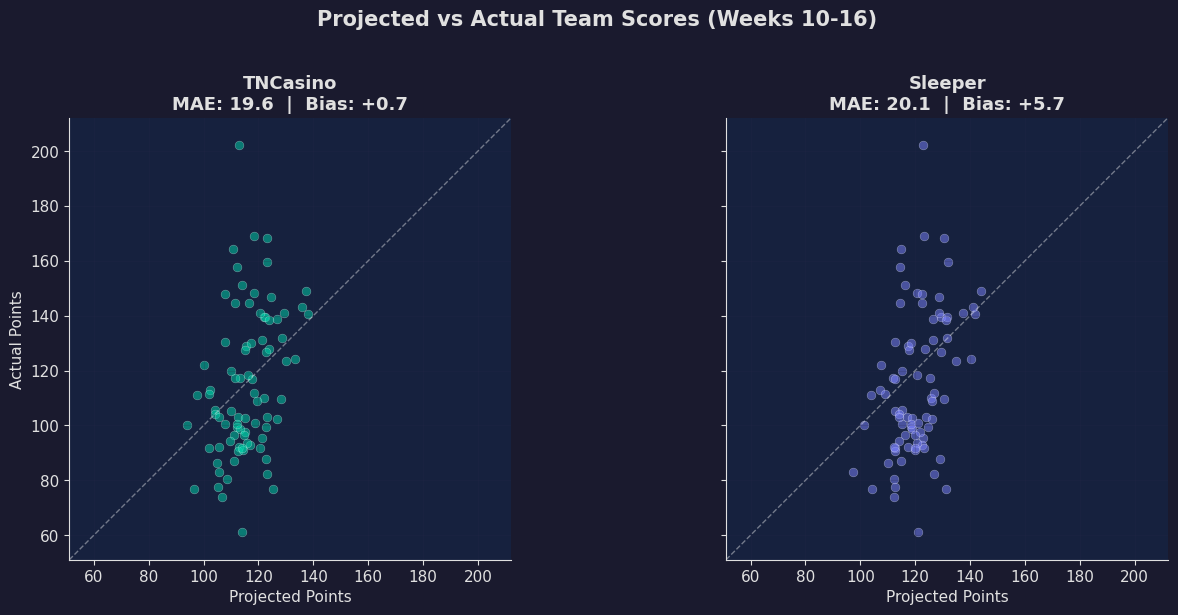

In [12]:
# --- Projected vs Actual scatter ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, proj_col, label, color in [
    (axes[0], "blended_proj", "TNCasino", TNCASINO_COLOR),
    (axes[1], "sleeper_proj", "Sleeper", SLEEPER_COLOR),
]:
    ax.scatter(team_comparison[proj_col], team_comparison["actual"],
               alpha=0.5, s=40, color=color, edgecolors="white", linewidth=0.3)
    lo = min(team_comparison[proj_col].min(), team_comparison["actual"].min()) - 10
    hi = max(team_comparison[proj_col].max(), team_comparison["actual"].max()) + 10
    ax.plot([lo, hi], [lo, hi], "--", color="#ffffff", alpha=0.4, linewidth=1)
    mae = (team_comparison[proj_col] - team_comparison["actual"]).abs().mean()
    bias = (team_comparison[proj_col] - team_comparison["actual"]).mean()
    ax.set_xlabel("Projected Points")
    ax.set_title(f"{label}\nMAE: {mae:.1f}  |  Bias: {bias:+.1f}", fontsize=13, fontweight="bold")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Actual Points")
fig.suptitle("Projected vs Actual Team Scores (Weeks 10-16)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

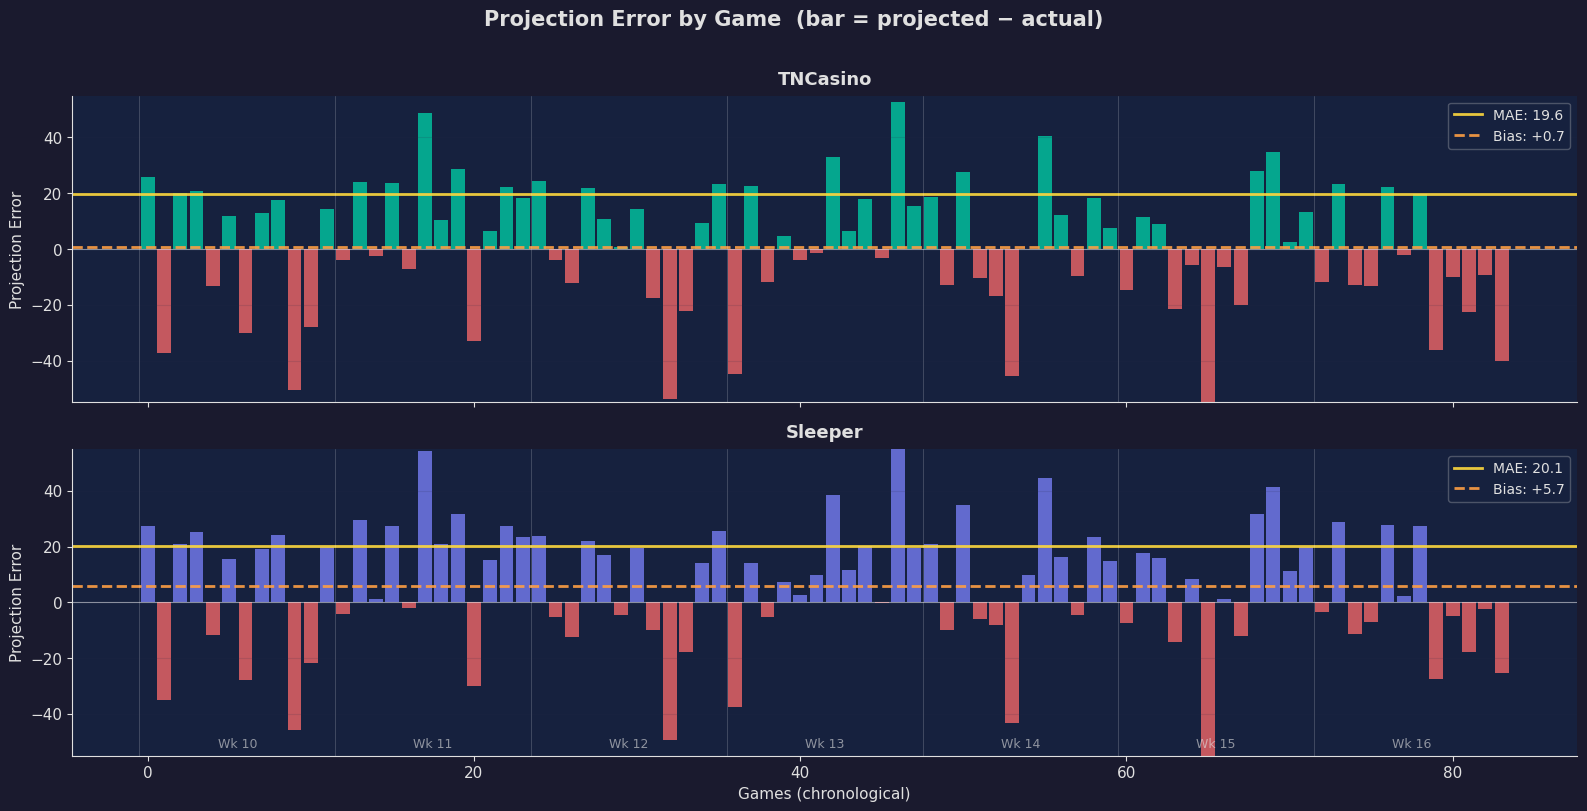

In [13]:
# --- Chronological error bars ---
tc_chrono = team_comparison.sort_values(["week", "roster_id"]).reset_index(drop=True)
tc_chrono["our_residual"] = tc_chrono["blended_proj"] - tc_chrono["actual"]
tc_chrono["sleeper_residual"] = tc_chrono["sleeper_proj"] - tc_chrono["actual"]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, residual_col, label, color in [
    (axes[0], "our_residual", "TNCasino", TNCASINO_COLOR),
    (axes[1], "sleeper_residual", "Sleeper", SLEEPER_COLOR),
]:
    residuals = tc_chrono[residual_col]
    bar_colors = [color if r >= 0 else "#ff6b6b" for r in residuals]
    ax.bar(range(len(tc_chrono)), residuals, color=bar_colors, alpha=0.75, width=0.85, edgecolor="none")
    ax.axhline(0, color="#ffffff", linewidth=0.8, alpha=0.5)
    mae = residuals.abs().mean()
    bias = residuals.mean()
    ax.axhline(mae, color="#ffd93d", linewidth=2, alpha=0.9, label=f"MAE: {mae:.1f}")
    ax.axhline(bias, color="#ff9f43", linewidth=2, linestyle="--", alpha=0.9, label=f"Bias: {bias:+.1f}")
    ax.set_ylabel("Projection Error")
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylim(-55, 55)
    ax.grid(True, axis="y", alpha=0.15)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", fontsize=10, framealpha=0.3)

week_starts = tc_chrono.groupby("week").apply(lambda g: g.index[0], include_groups=False)
for week, idx in week_starts.items():
    for ax in axes:
        ax.axvline(idx - 0.5, color="#ffffff", linewidth=0.5, alpha=0.25)
    axes[1].text(idx + 5.5, -52, f"Wk {week}", ha="center", fontsize=9, alpha=0.6)
axes[1].set_xlabel("Games (chronological)")
fig.suptitle("Projection Error by Game  (bar = projected \u2212 actual)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

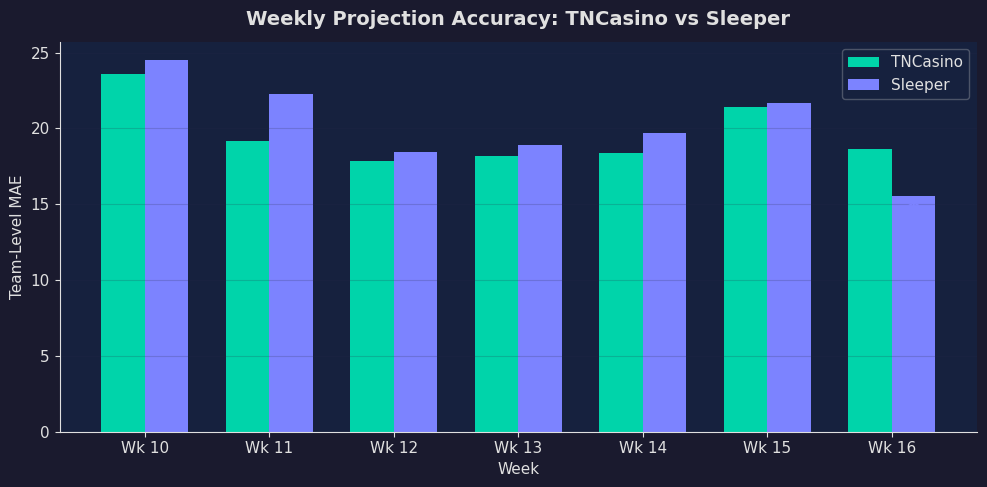

Weekly record: TNCasino 6 - 1 Sleeper


In [14]:
# --- Weekly MAE bar chart ---
weekly = team_comparison.groupby("week").agg(
    our_mae=("our_error", "mean"), sleeper_mae=("sleeper_error", "mean"),
).reset_index()
weekly["we_won"] = weekly["our_mae"] < weekly["sleeper_mae"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(weekly))
width = 0.35
ax.bar(x - width / 2, weekly["our_mae"], width, label="TNCasino", color=TNCASINO_COLOR, edgecolor="none")
ax.bar(x + width / 2, weekly["sleeper_mae"], width, label="Sleeper", color=SLEEPER_COLOR, edgecolor="none")
ax.set_xlabel("Week")
ax.set_ylabel("Team-Level MAE")
ax.set_title("Weekly Projection Accuracy: TNCasino vs Sleeper", fontsize=14, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels([f"Wk {int(w)}" for w in weekly["week"]])
ax.legend(framealpha=0.3)
ax.grid(True, axis="y", alpha=0.2)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
for i, (_, row) in enumerate(weekly.iterrows()):
    wy = min(row["our_mae"], row["sleeper_mae"]) - 1.2
    wx = x[i] - width / 2 if row["we_won"] else x[i] + width / 2
    ax.text(wx, wy, "*", ha="center", fontsize=16, fontweight="bold",
            color=TNCASINO_COLOR if row["we_won"] else SLEEPER_COLOR)
plt.tight_layout()
plt.show()

our_wins = weekly["we_won"].sum()
print(f"Weekly record: TNCasino {our_wins} - {len(weekly) - our_wins} Sleeper")

---
## 5. Over/Under Line Accuracy

Our Monte Carlo simulation sets an O/U line for each team each week. How well calibrated were those lines?

In [15]:
# Load O/U lines and join to actuals
ou_lines = pd.read_sql("""
    SELECT week, team_id, owner, line, over_prob FROM betting_odds_team_ou
""", conn_odds)

ou_merged = ou_lines.merge(
    team_comparison[["week", "owner", "actual", "sleeper_proj"]],
    on=["week", "owner"]
)
ou_merged["diff"] = ou_merged["actual"] - ou_merged["line"]
ou_merged["result"] = np.where(ou_merged["diff"] > 0, "OVER", "UNDER")
ou_merged["our_line_error"] = ou_merged["diff"].abs()
ou_merged["sleeper_line_error"] = (ou_merged["sleeper_proj"] - ou_merged["actual"]).abs()

overs = (ou_merged["result"] == "OVER").sum()
unders = (ou_merged["result"] == "UNDER").sum()
print(f"Results: {overs} overs / {unders} unders out of {len(ou_merged)} lines")
print(f"Our line MAE:     {ou_merged['our_line_error'].mean():.1f} pts")
print(f"Sleeper line MAE: {ou_merged['sleeper_line_error'].mean():.1f} pts")
print(f"Line bias:        {ou_merged['diff'].mean():+.1f} pts (positive = actuals exceeded lines)")

Results: 33 overs / 39 unders out of 72 lines
Our line MAE:     20.0 pts
Sleeper line MAE: 20.7 pts
Line bias:        +2.6 pts (positive = actuals exceeded lines)


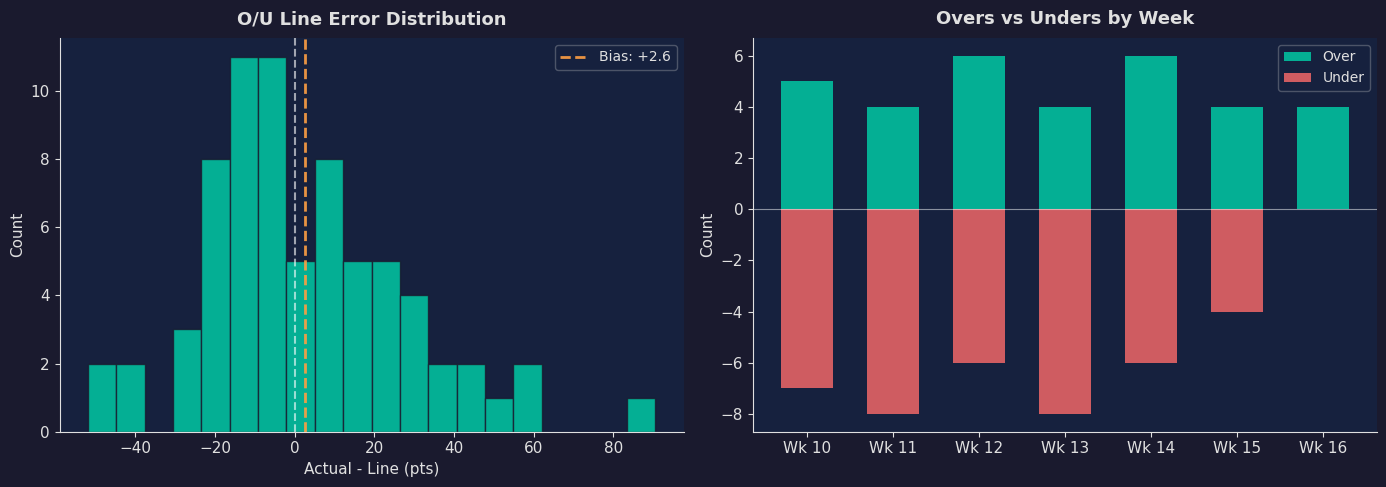

In [16]:
# --- O/U residual distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of (actual - line)
ax = axes[0]
diffs = ou_merged["diff"]
ax.hist(diffs, bins=20, color=TNCASINO_COLOR, edgecolor="#1a1a2e", alpha=0.8)
ax.axvline(0, color="#ffffff", linewidth=1.5, linestyle="--", alpha=0.6)
ax.axvline(diffs.mean(), color="#ff9f43", linewidth=2, linestyle="--", alpha=0.9, label=f"Bias: {diffs.mean():+.1f}")
ax.set_xlabel("Actual - Line (pts)")
ax.set_ylabel("Count")
ax.set_title("O/U Line Error Distribution", fontsize=13, fontweight="bold", pad=10)
ax.legend(fontsize=10, framealpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Weekly over/under split
ax = axes[1]
weekly_ou = ou_merged.groupby("week").agg(
    overs=("result", lambda x: (x == "OVER").sum()),
    unders=("result", lambda x: (x == "UNDER").sum()),
).reset_index()
x = np.arange(len(weekly_ou))
ax.bar(x, weekly_ou["overs"], width=0.6, label="Over", color=TNCASINO_COLOR, alpha=0.8)
ax.bar(x, -weekly_ou["unders"], width=0.6, label="Under", color="#ff6b6b", alpha=0.8)
ax.axhline(0, color="#ffffff", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f"Wk {int(w)}" for w in weekly_ou["week"]])
ax.set_ylabel("Count")
ax.set_title("Overs vs Unders by Week", fontsize=13, fontweight="bold", pad=10)
ax.legend(fontsize=10, framealpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# --- Line accuracy: our line vs Sleeper's ---
our_closer = (ou_merged["our_line_error"] < ou_merged["sleeper_line_error"]).sum()
sleeper_closer = (ou_merged["sleeper_line_error"] < ou_merged["our_line_error"]).sum()
ties = len(ou_merged) - our_closer - sleeper_closer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MAE comparison bar
ax = axes[0]
models = ["TNCasino", "Sleeper"]
maes = [ou_merged["our_line_error"].mean(), ou_merged["sleeper_line_error"].mean()]
bar_colors = [TNCASINO_COLOR, SLEEPER_COLOR]
bars = ax.bar(models, maes, color=bar_colors, edgecolor="none", width=0.5)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f"{val:.1f}", ha="center", fontsize=13, fontweight="bold", color="#e0e0e0")
ax.set_ylabel("Mean Absolute Error (pts)")
ax.set_title("O/U Line MAE", fontsize=13, fontweight="bold", pad=10)
ax.set_ylim(0, max(maes) * 1.25)
ax.grid(True, axis="y", alpha=0.15)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Right: who set the closer line more often
ax = axes[1]
categories = ["TNCasino\ncloser", "Sleeper\ncloser"]
counts = [our_closer, sleeper_closer]
bars = ax.bar(categories, counts, color=[TNCASINO_COLOR, SLEEPER_COLOR], edgecolor="none", width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            str(val), ha="center", fontsize=13, fontweight="bold", color="#e0e0e0")
ax.set_ylabel("Team-weeks")
ax.set_title(f"Who Set the Better Line? ({len(ou_merged)} total)", fontsize=13, fontweight="bold", pad=10)
ax.set_ylim(0, max(counts) * 1.25)
ax.grid(True, axis="y", alpha=0.15)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---
## 5. Matchup Prediction Scoreboard

For each head-to-head matchup: did our projected team totals correctly predict the winner?

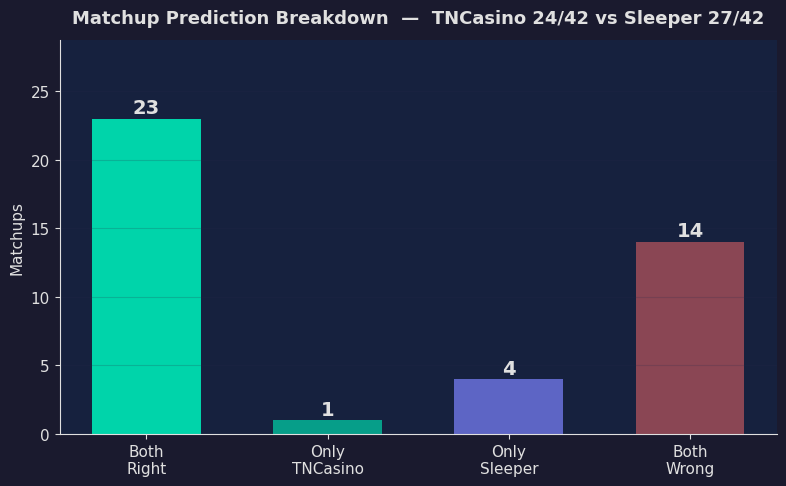

In [18]:
tc = team_comparison.copy()
pairs = tc.merge(tc, on=["week", "matchup_id"], suffixes=("_a", "_b"))
pairs = pairs[pairs["roster_id_a"] < pairs["roster_id_b"]].copy()
pairs["actual_winner"] = np.where(pairs["actual_a"] > pairs["actual_b"], pairs["owner_a"], pairs["owner_b"])
pairs["our_pick"] = np.where(pairs["blended_proj_a"] > pairs["blended_proj_b"], pairs["owner_a"], pairs["owner_b"])
pairs["sleeper_pick"] = np.where(pairs["sleeper_proj_a"] > pairs["sleeper_proj_b"], pairs["owner_a"], pairs["owner_b"])
pairs["our_correct"] = pairs["our_pick"] == pairs["actual_winner"]
pairs["sleeper_correct"] = pairs["sleeper_pick"] == pairs["actual_winner"]

our_record = int(pairs["our_correct"].sum())
sleeper_record = int(pairs["sleeper_correct"].sum())
total_matchups = len(pairs)
we_right_they_wrong = int(((pairs["our_correct"]) & (~pairs["sleeper_correct"])).sum())
they_right_we_wrong = int(((~pairs["our_correct"]) & (pairs["sleeper_correct"])).sum())
both_right = int(((pairs["our_correct"]) & (pairs["sleeper_correct"])).sum())
both_wrong = int(((~pairs["our_correct"]) & (~pairs["sleeper_correct"])).sum())

# --- Breakdown visual ---
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Both\nRight", "Only\nTNCasino", "Only\nSleeper", "Both\nWrong"]
values = [both_right, we_right_they_wrong, they_right_we_wrong, both_wrong]
bar_colors = [TNCASINO_COLOR, TNCASINO_COLOR, SLEEPER_COLOR, "#ff6b6b"]
bar_alphas = [1.0, 0.7, 0.7, 0.5]

bars = ax.bar(categories, values, color=bar_colors, edgecolor="none", width=0.6)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            str(val), ha="center", fontsize=14, fontweight="bold", color="#e0e0e0")
ax.set_ylabel("Matchups")
ax.set_title(f"Matchup Prediction Breakdown  \u2014  TNCasino {our_record}/{total_matchups} vs Sleeper {sleeper_record}/{total_matchups}",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(0, max(values) * 1.25)
ax.grid(True, axis="y", alpha=0.2)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [19]:
# Detailed scoreboard
for week in sorted(pairs["week"].unique()):
    wp = pairs[pairs["week"] == week]
    print(f"\n--- Week {week} ---")
    for _, g in wp.iterrows():
        our_mark = "OK" if g["our_correct"] else "X "
        slp_mark = "OK" if g["sleeper_correct"] else "X "
        print(
            f"  {g['owner_a']:20s} ({g['actual_a']:5.1f}) vs "
            f"{g['owner_b']:20s} ({g['actual_b']:5.1f})  |  "
            f"Us: {our_mark}  Sleeper: {slp_mark}"
        )


--- Week 10 ---
  xavierking4          ( 95.5) vs sfaizi24             ( 98.8)  |  Us: X   Sleeper: X 
  asadrafique          (151.2) vs TBK41                (128.9)  |  Us: X   Sleeper: X 
  amir812              (103.0) vs umarrahman30         ( 92.0)  |  Us: OK  Sleeper: OK
  Jibraan              (110.1) vs sahirsyed30          ( 99.3)  |  Us: OK  Sleeper: OK
  mehdidrissi          (148.4) vs monkeyman966699696   (169.0)  |  Us: X   Sleeper: OK
  Bilal879             ( 97.8) vs Ammady               (144.4)  |  Us: OK  Sleeper: OK

--- Week 11 ---
  xavierking4          (127.8) vs Jibraan              ( 76.8)  |  Us: X   Sleeper: X 
  asadrafique          ( 93.0) vs umarrahman30         ( 87.1)  |  Us: OK  Sleeper: OK
  amir812              (140.5) vs TBK41                (143.2)  |  Us: X   Sleeper: X 
  mehdidrissi          ( 91.7) vs Ammady               ( 93.5)  |  Us: OK  Sleeper: OK
  sahirsyed30          ( 91.8) vs sfaizi24             ( 96.3)  |  Us: X   Sleeper: X 
  Bilal87

In [20]:
conn_proj.close()
conn_league.close()
conn_odds.close()
conn_mc.close()